In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Local mapping tutorial

Please follow this [link]("https://drive.google.com/drive/folders/1-LUEad1iy5DNDZmKjQoPTz8ehMYDj91l?usp=drive_link") to access all the files needed to run this notebook. Please download the folder "hlca_tutorial" and make sure that your local folder where the files are stored is also named "hlca_tutorial". If the link does not work, please copy and paste the link string into your browser. 

The data_only_count.h5ad is only needed if you would like to include the reference count data in your final mapped output for downstream analysis. The gene_conversions are only needed if you are using your own mapping and not the query data provided. 

If you are mapping a query to another reference, please make sure that the gene_conversions folder is in your path that you set in the below cell (the path variable). This folder can be obtained from the link above, in the hlca_tutorial folder. Also, make sure to set the following variables in the cells below:

**path** - The path to your atlas, model, and query files (all files needed for mapping).\
**query_adata_path** - The name of your query file.\
**atlas** - The name of your atlas (please make sure that you use lowercase letters for file names).\
**model_type** - The model used for integration (scANVI, scVI, or scPoli).\
**max_epochs** - Number of epochs to use for mapping. The default is set to 50.\
**batch_key** - The batch covariate key in the reference representing technical batch variation (eg sample or dataset). Leave as None if you are using an atlas from ArchMap.\
**batch_key_input** - The batch covariate key in the query dataset representing technical batch variation.\
**cell_type_key** - The cell type key to be used for label transfer. Leave as None to use the default key(s) from ArchMap\
**use_XGB** - Set to True to use XGBoost for label transfer\
**use_KNN** - Set to True to use KNN for label transfer


If you are using an atlas that is not on ArchMap, please make sure that you use lowercase letters for all file names. Also please make sure that you set the batch_key and cell_type_key variables with the corresponding keys used during integration of your atlas. If scVI was used for integration, cell_type_key should be set to the labels you would like to be transferred to the query.


If you have any issues or questions please don't hesitate to reach out at archmap.bio@gmail.com :) 

In [22]:
import scanpy as sc

In [ ]:
path = "hlca_tutorial/" 
query_adata_path = path + "hlca_healthy.h5ad"
atlas = "HLCA"
model_type = "SCANVI"
max_epochs = 100
batch_key = None #Leave as None if you are using an atlas from ArchMap.
batch_key_input = "batch"
cell_type_key = None #Leave as None if you are using an atlas from ArchMap.
use_XGB = False
use_KNN = True


configuration = {
    "model": model_type,
    "atlas": atlas,
    "batch_key": batch_key,
    "cell_type_key": cell_type_key,
    "output_type": {
        "csv": False,
        "cxg": True,
    },
    "classifier_type": {
        "XGBoost": use_XGB,
        "kNN": use_KNN,
    },
    "n_neighbors": 8,
}

In [24]:
import scarches
import scanpy
import pandas
import numpy as np
import tempfile
import gc
import numpy as np
from scipy.sparse import csr_matrix
from anndata import experimental
import scanpy as sc
import os
from scarches_api.utils import parameters
from scarches_api.utils.metrics import estimate_presence_score, cluster_preservation_score, percent_query_with_anchor, get_wknn
from scarches_api.utils.utils import get_from_config
from scarches_api.utils.utils import replace_X_on_disk, validate_h5ad
import pandas as pd

from process.processing import Preprocess
from process.processing import Postprocess

from scarches_api.uncert.uncert_metric import classification_uncert_euclidean
from scarches_api.uncert.uncert_metric import classification_uncert_mahalanobis

from classifiers.classifiers import Classifiers 
import torch

In [25]:
atlas = atlas.lower()
model_type = model_type.lower()

def acquire_data():
    #Download query and reference from GCP
      
    reference_adata = sc.read(path + "model_" + atlas + "_" + model_type + "/adata.h5ad")

    reference_adata.obs["type"] = "reference"
    del reference_adata.layers

    try:
        query_adata_raw = sc.read(query_adata_path) 
        print("Data successfully loaded.")
    except Exception as e:
        raise RuntimeError(f"Error message: {e}, There is likely an issue with the way your data (anndata object) is formatted upon upload. Please reach out to ArchMap (archmap.bio@gmail.com) with a screenshot of this error and we can help resolve this.")

    validate_h5ad(query_adata_raw)
    
    try:

        temp_query = tempfile.NamedTemporaryFile(suffix=".h5ad")
        query_adata_raw.write_h5ad(temp_query.name)
    except ValueError as e:
        if "is also used by a column whose values are different" in str(e):
            raise ValueError(f"Error message: {e}, Please check your anndata object for columns in .obs and .var that have matching names and delete duplicates") from e
        else:
            raise ValueError(f"Error message: {e}. There is likely an issue with the way your data (anndata object) is formatted upon upload. Please reach out to ArchMap (archmap.bio@gmail.com) with a screenshot of this error and we can help resolve this.")
        



    query_adata_raw.obs["type"] = "query"

    # Check if var_names of ref and query match. Convert var_names of query if not.
    ensembl_ref = True
    for var_name in reference_adata.var_names[:5]:
        if "ENS" in var_name: 
            continue
        else:
            ensembl_ref = False
            break

    ensembl_query = True
    for var_name in query_adata_raw.var_names[:5]:
        if "ENS" in var_name: 
            continue
        else:
            ensembl_query = False
            break


    if ensembl_query != ensembl_ref: 
        import pickle
        # convert query var_names to match ref

        if ensembl_ref == True:
            if "ENSMUS" in reference_adata.var_names[0]:

                with open(f"gene_conversions/genesymbol_to_ensembl_mouse.pkl", "rb") as file:
                    dict_conversions = pickle.load(file)

            else:
                with open(f"gene_conversions/genesymbol_to_ensembl_human.pkl", "rb") as file:
                    dict_conversions = pickle.load(file)
                
    
        else:
            if "ENSMUS" in query_adata_raw.var_names[0]:
                #fetch mouse conversions
                with open(f"gene_conversions/ensembl_to_genesymbol_mouse.pkl", "rb") as file:
                    dict_conversions = pickle.load(file)

            else:
                with open(f"gene_conversions/ensembl_to_genesymbol_human.pkl", "rb") as file:
                    dict_conversions = pickle.load(file)

        query_adata_raw.var_names = pd.Index([dict_conversions.get(item, item) for item in query_adata_raw.var_names])

    ref_vars = reference_adata.var_names
    query_vars = query_adata_raw.var_names
    
    intersection = ref_vars.intersection(query_vars)
    inter_len = len(intersection)
    ratio = (inter_len / len(ref_vars))*100

    print(f"{ratio}% of genes in your query overlap with the reference data")
    if int(ratio)<50:
        raise ValueError(f"Less than 50% of genes (exactly {ratio}%) in your query overlap with the reference data. This will result in a poor mapping quality. Please make sure that the correct information is stored in .var_names and you have chosen the correct atlas for your dataset.")


    query_adata_raw.obs_names_make_unique()
    query_adata_raw.var_names_make_unique()

    #Convert bool to categorical to avoid write error during concatenation
    Preprocess.bool_to_categorical(reference_adata)
    Preprocess.bool_to_categorical(query_adata_raw)

    
    # save only necessary data for mapping to new adata
    query_adata = query_adata_raw.copy()
    del query_adata.varm
    del query_adata.obsm
    del query_adata.layers
    del query_adata.uns
    del query_adata.obsp
    del query_adata.varp

    query_adata.layers['counts'] = query_adata.X

    return query_adata, reference_adata

In [26]:
# Intialize variables
model_file = path + "model_" + atlas + "_" + model_type + "/model.pt"
model_path = path + "model_" + atlas 
model = None
temp_clf_model_path = None
temp_clf_encoding_path = None
query_adata = None
reference_adata = None
combined_adata = None
percent_unknown = "n/a"

#Load and process required data
query_adata, reference_adata = acquire_data()

#Set respective keys coherent to chosen atlas
cell_type_key = None
unlabeled_key = None
cell_type_key_input = "user_cell_type"

if batch_key_input != "batch":
    query_adata.obs["batch"] = query_adata.obs[batch_key_input]

else:
    query_adata.obs["batch"]="batch"


query_adata.X=query_adata.X.tocsr()

cell_type_key, cell_type_key_classifier, cell_type_key_list, batch_key, unlabeled_key, uploaded = Preprocess.get_keys(atlas, query_adata, configuration, model_file) 

if isinstance(cell_type_key,list):
    for key in cell_type_key:
        query_adata.obs[key] = [unlabeled_key]*len(query_adata) 
else:
    query_adata.obs[cell_type_key] = [unlabeled_key]*len(query_adata)

if cell_type_key_classifier is None:
    cell_type_key_classifier = cell_type_key

if cell_type_key_list is None:
    if isinstance(cell_type_key_classifier,list):
        cell_type_key_list = cell_type_key_classifier
    else:
        cell_type_key_list = [cell_type_key_classifier]

if batch_key_input != batch_key:
    query_adata.obs[batch_key] = query_adata.obs[batch_key_input].copy()
    del query_adata.obs[batch_key_input]



clf_xgb = get_from_config(configuration=configuration, key=parameters.CLASSIFIER_TYPE).get("XGBoost")
clf_knn = get_from_config(configuration=configuration, key=parameters.CLASSIFIER_TYPE).get("kNN")


Data successfully loaded.
96.8% of genes in your query overlap with the reference data


Map Query

In [27]:
def compute_latent_representation(explicit_representation):
        #Setup adata before quering model for latent representation
        scarches.models.SCANVI.setup_anndata(explicit_representation, labels_key=cell_type_key, unlabeled_category="unlabeled", batch_key=batch_key)
        explicit_representation.obsm["latent_rep"] = model.get_latent_representation(explicit_representation)


In [28]:
supervised=False
model_path = path + "model_" + atlas + "_" + model_type 
query_adata.var_names_make_unique()

if model_type!= "scpoli":

    # backwards compatibility for older models
    loadedmodel=torch.load(model_path + "/model.pt")
    if "setup_method_name" not in loadedmodel["attr_dict"]["registry_"].keys():
        loadedmodel["attr_dict"]["registry_"]["setup_method_name"] = "setup_anndata"
        torch.save(loadedmodel, model_path + "/model.pt")
        
    if model_type == "scanvi":
        print("Training using scANVI model")
        scarches.models.SCANVI.prepare_query_anndata(query_adata, model_path)

        #Setup adata internals for mapping
        scarches.models.SCANVI.setup_anndata(query_adata, batch_key=batch_key, labels_key=cell_type_key, unlabeled_category=unlabeled_key)

        #Load scanvi model with query
        model = scarches.models.SCANVI.load_query_data(
            query_adata,
            model_path,
            freeze_dropout=True,
        )

        #Check if mapping supervised, unsupervised or semi-supervised
        if supervised:
            model._unlabeled_indices = []
            model._labeled_indices = query_adata.n_obs
        else:
            model._unlabeled_indices = np.arange(query_adata.n_obs)
            model._labeled_indices = []

    elif model_type == "scvi":
        print("Training using scVI model")
        scarches.models.SCVI.prepare_query_anndata(query_adata, model_path)

        #Setup adata internals for mapping
        scarches.models.SCVI.setup_anndata(query_adata, batch_key=batch_key, labels_key=cell_type_key)

        #Load scvi model with query
        model = scarches.models.SCVI.load_query_data(
            query_adata,
            model_path,
            freeze_dropout=True,
        )

    #Map the query onto reference
    lr=0.001

    try: 
        model.train(
            max_epochs=max_epochs,
            plan_kwargs=dict(weight_decay=0.0,lr=lr),
            check_val_every_n_epoch=10,
        )
    except ValueError as e:
        if "Expected parameter loc" in str(e):
            raise ValueError("Please check that your anndata object has raw counts (not normalized) saved in adata.X. Mapping can only occur with raw count data.") from e
        else:
            raise

    if "X_latent_qzm" in reference_adata.obsm and "X_latent_qzv" in reference_adata.obsm:
        print("__________getting X_latent_qzm from minified atlas for scvi-tools models___________")
        qzm = reference_adata.obsm["X_latent_qzm"]
        reference_adata.obsm["latent_rep"] = qzm

    else:
        raise ValueError("No embedding saved in the reference adata object. Please make sure you save the latent representation of the reference atlas under 'X_latent_qzm_scpoli' in the reference .obsm attribute.")


    #Save out the latent representation for QUERY
    compute_latent_representation(explicit_representation=query_adata)

else:
    print("Training using scPoli model")
    model = scarches.models.scPoli.load_query_data(
            adata=query_adata,
            reference_model=model_path,
            labeled_indices=[],
            map_location=torch.device("cpu")
        )

    query_adata = model.adata

    
    try:
        model.train(
            n_epochs=max_epochs,
            pretraining_epochs=40,
            eta=10
        )
    except ValueError as e:
        if "Expected parameter loc" in str(e):
            raise ValueError("Please check that your anndata object has raw counts (not normalized) saved in adata.X. Mapping can only occur with raw count data.") from e
        else:
            raise
    

    if "X_latent_qzm_scpoli" in reference_adata.obsm:

        qzm = reference_adata.obsm["X_latent_qzm_scpoli"]
        reference_adata.obsm["latent_rep"] = qzm

        #Save out the latent representation for QUERY
        query_adata.obsm["latent_rep"] = model.get_latent(query_adata, mean=True)

    else:
        raise ValueError("No embedding saved in the reference adata object. Please make sure you save the latent representation of the reference atlas under 'X_latent_qzm_scpoli' in the reference .obsm attribute.")






Training using scANVI model
INFO     File hlca_tutorial/model_hlca_scanvi/model.pt already downloaded                                          
INFO     Found 96.8% reference vars in query data.                                                                 
INFO     File hlca_tutorial/model_hlca_scanvi/model.pt already downloaded                                          
INFO     Training for 1 epochs.                                                                                    


INFO: GPU available: True (mps), used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (mps), used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


Epoch 1/1: 100%|██████████| 1/1 [00:06<00:00,  6.78s/it, v_num=1, train_loss_step=509, train_loss_epoch=528]

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 1/1: 100%|██████████| 1/1 [00:06<00:00,  6.79s/it, v_num=1, train_loss_step=509, train_loss_epoch=528]
__________getting X_latent_qzm from minified atlas for scvi-tools models___________


Evaluate Mapping

In [29]:
#Create AnnData objects off the latent representation
query_latent = scanpy.AnnData(query_adata.obsm["latent_rep"])
reference_latent = scanpy.AnnData(reference_adata.obsm["latent_rep"])
reference_latent.obs = reference_adata.obs

#Calculate mapping uncertainty and write into .obs
knn_ref_trainer= classification_uncert_euclidean(configuration, reference_latent, query_latent, query_adata, "X", cell_type_key_list, False)
classification_uncert_mahalanobis(configuration, reference_latent, query_latent, query_adata, cell_type_key_list, False)


Weighted KNN with n_neighbors = 15 ... finished!
finished!
finished!


Transfer labels

In [30]:
#Compute label transfer and save to respective .obs
query_latent = scanpy.AnnData(query_adata.obsm["latent_rep"])


clf = Classifiers(clf_xgb, clf_knn, None, model.__class__)

for cell_type_key in cell_type_key_list:
    
    clf_encoding_path = path + cell_type_key + "/classifier_encoding.pickle"

    #Download classifiers and encoding from GCP if kNN or XGBoost
    if clf_xgb:

        clf_model_path = path + cell_type_key + "/classifier_xgb.ubj"


    elif clf_knn:

        clf_model_path = path + cell_type_key + "/classifier_knn.pickle"

    # create classifiers if not already trained
    if not os.path.exists(clf_model_path):

        clf.create_classifier(reference_latent, reference_adata, True, "", cell_type_key, path + cell_type_key)

    percent_unknown = clf.predict_labels(query_adata, query_latent, clf_model_path, clf_encoding_path, cell_type_key)




Concatenate query and reference data

In [31]:
#save .X and var_names of query in new adata for later concatenation after cellxgene
adata_query_X = scanpy.AnnData(query_adata.X.copy())
adata_query_X.var_names = query_adata.var_names
#we can then zero out .X in original query
all_zeros = csr_matrix(query_adata.X.shape)

query_adata.X = all_zeros.copy()


latent_full_from_mean_var = np.concatenate((reference_adata.obsm["latent_rep"], query_adata.obsm["latent_rep"]))

query_adata.obs["query"]=["1"]*query_adata.n_obs
reference_adata.obs["query"]=["0"]*reference_adata.n_obs


print("concatenating on disk")
#Added because concat_on_disk only allows inner joins  
for cell_type_key in cell_type_key_list:
    reference_adata.obs[cell_type_key + '_uncertainty_euclidean'] = pandas.Series(dtype="float32")
    reference_adata.obs[cell_type_key + '_uncertainty_mahalanobis'] = pandas.Series(dtype="float32")
    reference_adata.obs[cell_type_key + '_prediction_xgb'] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + '_prediction_knn'] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_scanvi"] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_scpoli"] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_scpoli_filtered_by_uncert>0.5"] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_scanvi_filtered_by_uncert>0.5"] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_xgb_filtered_by_uncert>0.5"] = reference_adata.obs[cell_type_key]
    reference_adata.obs[cell_type_key + "_prediction_knn_filtered_by_uncert>0.5"] = reference_adata.obs[cell_type_key]

    query_adata.obs[cell_type_key] = pandas.Series(dtype="category")

for cell_type_key in cell_type_key_list:
    if "Unknown" not in query_adata.obs[cell_type_key].cat.categories:
        query_adata.obs[cell_type_key] = query_adata.obs[cell_type_key].cat.add_categories(["Unknown"])

    query_adata.obs[cell_type_key] = query_adata.obs[cell_type_key].fillna("Unknown").astype('category')

#Create temp files on disk
temp_reference = tempfile.NamedTemporaryFile(suffix=".h5ad")
temp_query = tempfile.NamedTemporaryFile(suffix=".h5ad")
temp_combined = tempfile.NamedTemporaryFile(suffix=".h5ad")


#Write data to temp files
reference_adata.write_h5ad(temp_reference.name)
query_adata.write_h5ad(temp_query.name)

#Concatenate on disk to save memory
experimental.concat_on_disk([temp_reference.name, temp_query.name], temp_combined.name)

query_obs_columns=set(query_adata.obs.columns)
ref_obs_columns=set(reference_adata.obs.columns)
columns_only_query = query_obs_columns.difference(ref_obs_columns)
query_obs = query_adata.obs[columns_only_query].copy()

del query_adata
gc.collect()

print("successfully concatenated")

#Read concatenated data back in
combined_adata = scanpy.read_h5ad(temp_combined.name)

# combined_adata.obs=combined_adata.obs[list(new_columns)]

print("read concatenated file")

combined_adata.obsm["latent_rep"] = latent_full_from_mean_var

combined_adata.obs_names_make_unique()

combined_adata.obs=pd.concat([combined_adata.obs,query_obs], axis=1)

print("added latent rep to adata")


concatenating on disk
successfully concatenated
read concatenated file
added latent rep to adata


Save data

If you would like to add the reference count data to your anndata object for downstream analysis post mapping you can set the add_counts parameter to True. Additionally, if you have storage limitations and would like to downsample the reference, you can set downsample_ref to True.

In [32]:
add_counts = True
downsample_ref = True

In [33]:
def downsample_adata(query_ratio=5):
        """
        Downsamples the reference data to be proportional to the query data.
        Proportional sampling based on cell type proportions.

        Parameters:
        query_ratio (int, optional): The ratio of reference to query data size. Default is 5.

        Returns:
        AnnData: Downsampled AnnData from combined data.
        """
        # Separate reference and query data
        ref_adata = combined_adata[combined_adata.obs["query"] == "0"]
        query_adata_index = np.where(combined_adata.obs["query"] == "1")[0]

        if isinstance(cell_type_key_classifier,list):
                celltype_key = cell_type_key_classifier[0]
        else:
            celltype_key = cell_type_key_classifier

        # New approach: Proportional sampling based on cell type proportions
        # Calculate total number of cells to sample from reference

        #change query ratio depending on query size
        if len(query_adata_index)<50000:
            total_ref_cells_to_sample = min(len(ref_adata),250000)
        else:
            total_ref_cells_to_sample = len(query_adata_index) * query_ratio


        celltypes = combined_adata.obs[celltype_key].unique()

        # Calculate the proportion of each cell type in the reference data
        celltype_proportions = {celltype: np.sum(ref_adata.obs[celltype_key] == celltype) / len(ref_adata) for celltype in celltypes}

        # Sample cells from each cell type according to its proportion
        sampled_cell_index = []
        for celltype, proportion in celltype_proportions.items():
            cell_indices = np.where(ref_adata.obs[celltype_key] == celltype)[0]
            sample_size = int(total_ref_cells_to_sample * proportion)
            
            # Adjust sample size if it exceeds the number of available cells
            if sample_size > len(cell_indices):
                sample_size = len(cell_indices)
            
            sampled_cells = np.random.choice(cell_indices, size=sample_size, replace=False)
            sampled_cell_index.extend(sampled_cells)
        
        # Combine sampled reference cells with query cells
        sampled_cell_index = np.concatenate([sampled_cell_index, query_adata_index])

        # Create downsampled AnnData object
        combined_downsample = combined_adata[sampled_cell_index].copy()

        return combined_downsample


In [34]:
def add_X(adata_query_X, combined_adata):

    count_matrix_path = path + "data_only_count.h5ad"

    temp_output_combined = "finetuned_model/adata.h5ad"
    os.makedirs("finetuned_model/", exist_ok=True)

    count_matrix = sc.read(count_matrix_path)

    print("Concatenating query and reference count matrices on disk")
    #Create temp files on disk
    temp_reference = tempfile.NamedTemporaryFile(suffix=".h5ad")
    temp_query = tempfile.NamedTemporaryFile(suffix=".h5ad")
    temp_combined = tempfile.NamedTemporaryFile(suffix=".h5ad")

    #Write data to temp files
    count_matrix.write_h5ad(temp_reference.name)
    adata_query_X.write_h5ad(temp_query.name)

    del count_matrix
    del adata_query_X
    gc.collect()

    experimental.concat_on_disk([temp_reference.name, temp_query.name], temp_combined.name)
    combined_data_X = sc.read_h5ad(temp_combined.name)

    combined_adata.X = combined_data_X.X
    sc.write(temp_output_combined, combined_adata)


    return combined_adata


Add X to joint anndata object (optional; see above) and calculate mapping scores

In [35]:
# add .X to combined_adata
if batch_key_input != batch_key:
    combined_adata.obs = combined_adata.obs.rename(columns={batch_key : batch_key_input})

if add_counts:
    print("adding counts")
    combined_adata = add_X(adata_query_X, combined_adata)

    if downsample_ref:
        combined_downsample = downsample_adata()
    else:
        combined_downsample = combined_adata.copy() 

else:
    print("not adding reference counts to final anndata object. To add counts, set add_counts variable to True")
    count_matrix = scanpy.AnnData(reference_adata.X)
    count_matrix.var_names = reference_adata.var_names
    combined_data_X = count_matrix.concatenate(adata_query_X)
    combined_adata.X = combined_data_X.X
    if downsample_ref:
        combined_downsample = downsample_adata()
    else:
        combined_downsample = combined_adata.copy() 

    del reference_adata
    gc.collect()


# Calculate presence score

print("Calculating mapping evaluation metrics ...")
ref_downsample = combined_downsample[combined_downsample.obs["query"]=="0"]
query_downsample = combined_downsample[combined_downsample.obs["query"]=="1"]

ref_latent_downsample = combined_downsample[combined_downsample.obs["query"]=="0"].obsm["latent_rep"]
query_latent_downsample = combined_downsample[combined_downsample.obs["query"]=="1"].obsm["latent_rep"]

knn_ref = knn_ref_trainer.fit_transform(ref_latent_downsample)

wknn, adjs = get_wknn(
    ref=ref_latent_downsample,
    query=query_latent_downsample,
    k=15,
    # adj_q2r=.knn_q2r,
    adj_ref=knn_ref,
    return_adjs=True
)

presence_score = estimate_presence_score(
    ref_downsample,
    query_downsample,
    wknn = wknn)


presence_score = np.concatenate((presence_score["max"],[np.nan]*len(query_downsample)))

combined_downsample.obs["presence_score"] = presence_score
print(f"presence_score: {presence_score}")

clust_pres_score=cluster_preservation_score(query_downsample)
print(f"clust_pres_score: {clust_pres_score}")

query_with_anchor=percent_query_with_anchor(adjs["r2q"], adjs["q2r"])
print(f"query_with_anchor: {query_with_anchor}")

print(f"percent_unknown: {percent_unknown}" )

import pickle
metric_dict = {"clust_pres_score":clust_pres_score, "query_with_anchor":query_with_anchor, "percentage_unknown": percent_unknown}
with open(f"{atlas}_evaluation_metrics.pickle", "wb") as file:
    pickle.dump(metric_dict, file)


#Save output
data_cxg = Postprocess.output(None, combined_downsample, configuration, store_file_in_cloud=False)

#save model and adata as tar file
import tarfile
os.makedirs("finetuned_model/", exist_ok=True)
data_cxg.write("finetuned_model/adata.h5ad")
model.save("finetuned_model/", save_anndata=False, overwrite=True)
output_filename="query_model.tar.gz"
source_dir="finetuned_model/"
with tarfile.open(output_filename, "w:gz") as tar:
    tar.add(source_dir, arcname=os.path.basename(source_dir))
print(f"Created tar archive: {output_filename}")





adding counts
Concatenating query and reference count matrices on disk
Calculating mapping evaluation metrics ...
Failed calling cuML. Falling back to neighborhood estimation using CPU with pynndescent.
Failed calling cuML. Falling back to neighborhood estimation using CPU with pynndescent.
Failed calling cuML. Falling back to neighborhood estimation using CPU with pynndescent.
presence_score: [0.   0.01 0.05 0.02 0.   0.01 0.01 ...  nan  nan  nan  nan  nan  nan  nan]
orig_ent: [40.62 40.62 43.51 40.62 40.62 40.62 45.13 ... 40.62 40.62 40.62 40.62
 40.62 45.13 40.62]
integrated_ent: [40.62 40.62 40.65 40.62 40.62 40.62 49.82 ... 40.62 40.62 40.62 41.47
 40.62 47.34 40.62]
clust_pres_score: 5.0
query_with_anchor: 12.86
percent_unknown: 16.23
X_umap not in obsm
neighbors
umap
Preparing output
Created tar archive: query_model.tar.gz


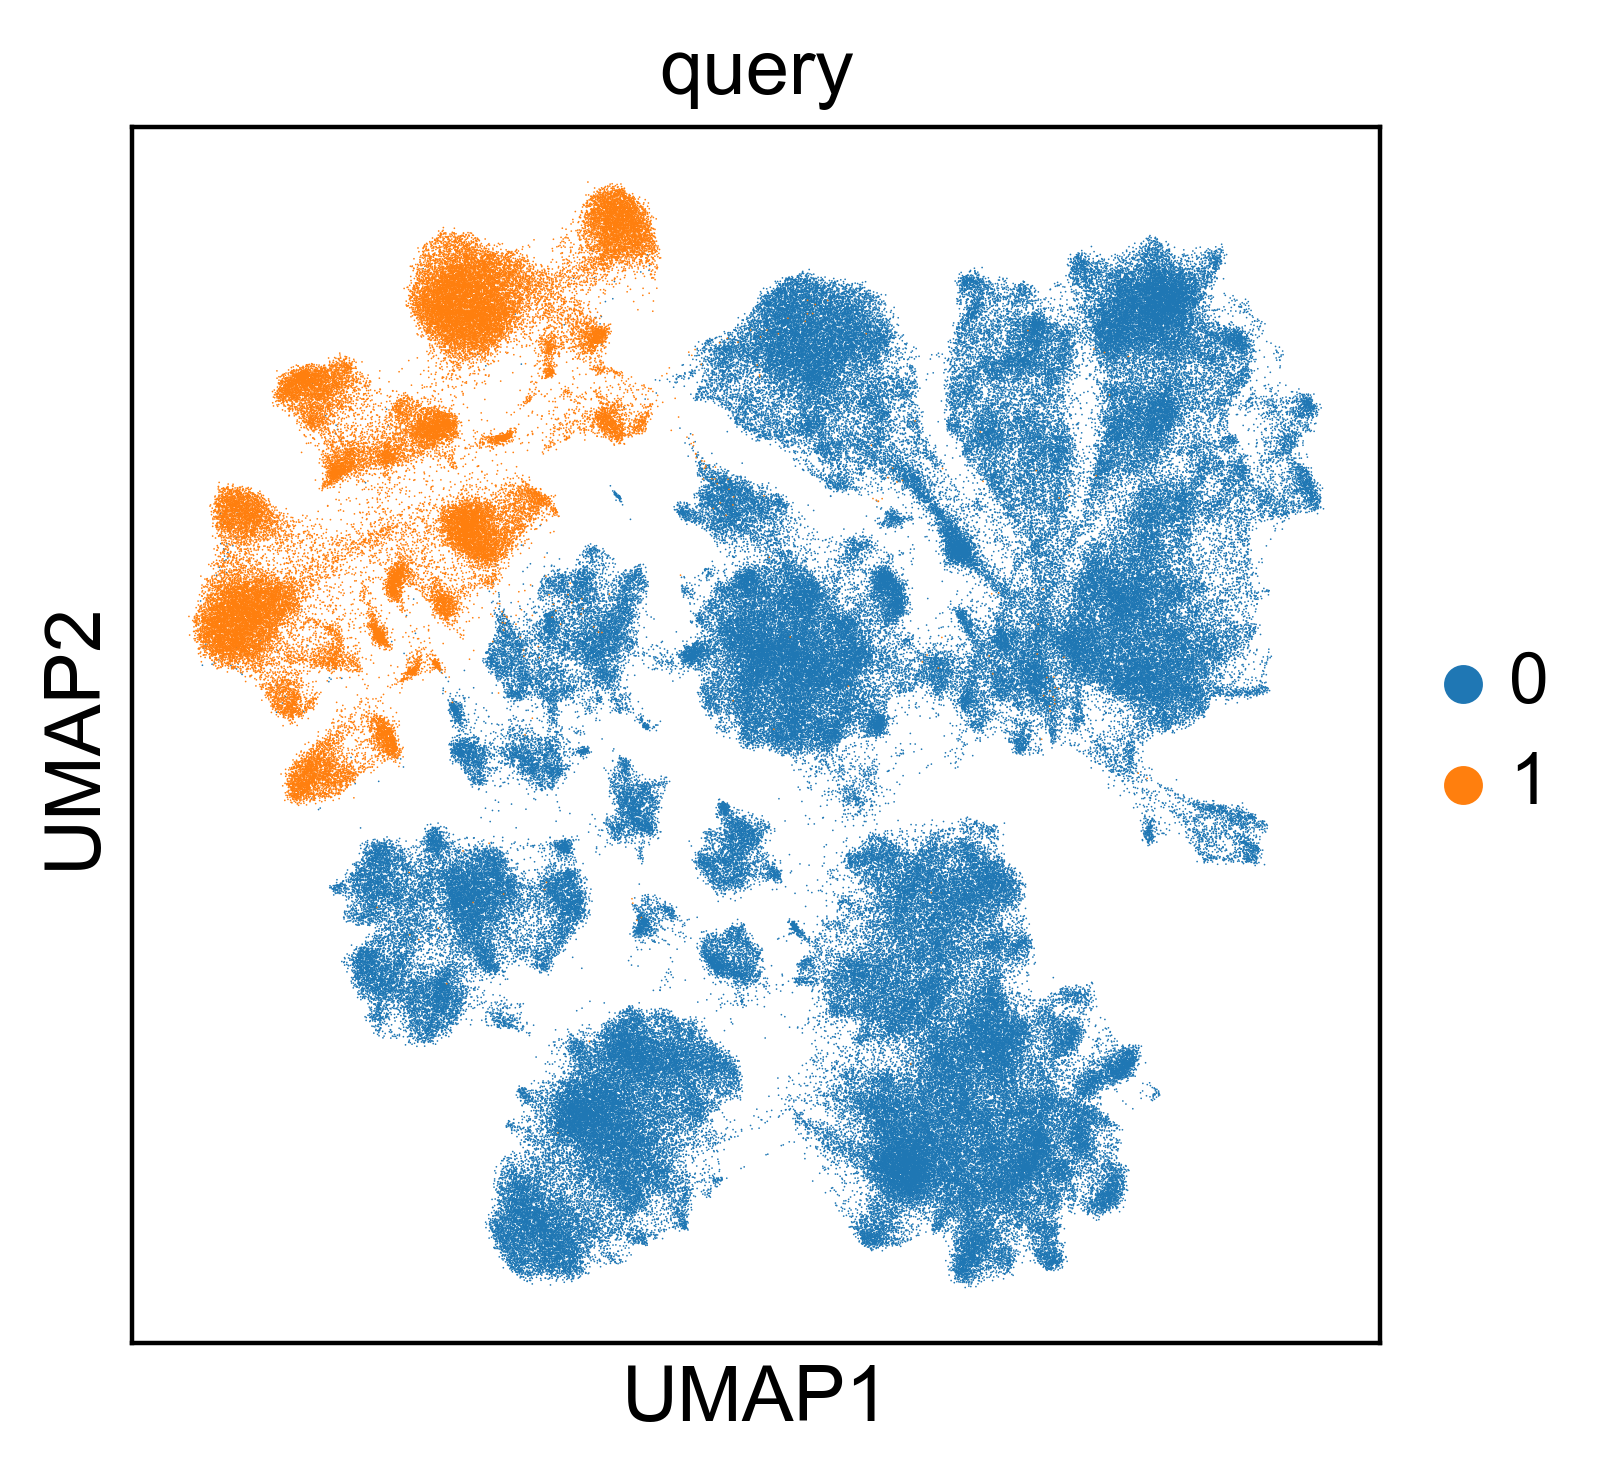

In [36]:
sc.pl.umap(data_cxg, color="query")